In [1]:
import sys
!"{sys.executable}" -m pip install matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
%pip install matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [13]:

# =========================
# 2. LOAD DATASET
# =========================
# Change path if needed
df = pd.read_csv("bank-additional-full.csv", sep=";")
df



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [14]:
df.shape


(41188, 21)

In [15]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [16]:

# =========================
# 3. BASIC DATA EXPLORATION
# =========================

print("\nMissing Values:\n", df.isnull().sum())




Missing Values:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [17]:

print("\nTarget Distribution:\n", df['y'].value_counts())

# Convert target variable
df['y'] = df['y'].map({'yes': 1, 'no': 0})


Target Distribution:
 y
no     36548
yes     4640
Name: count, dtype: int64


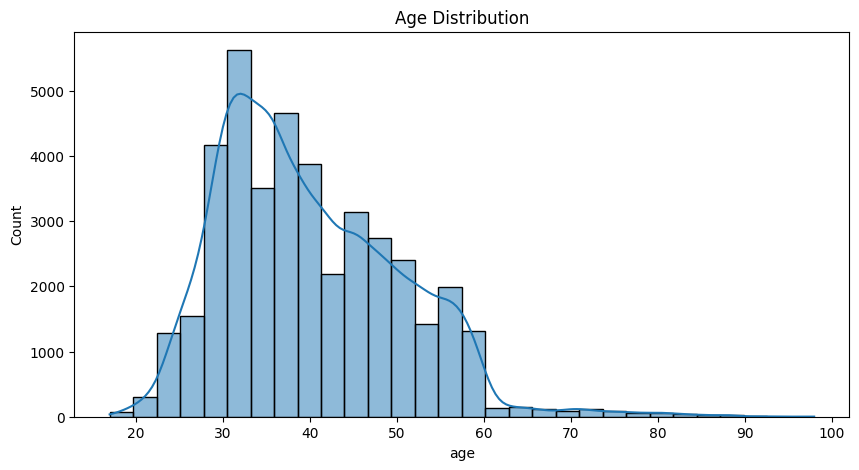

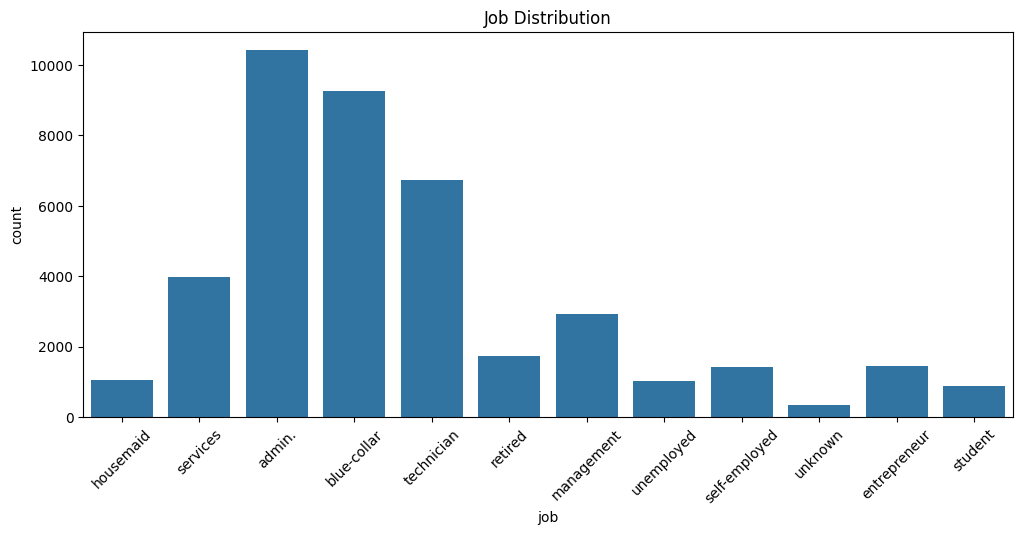

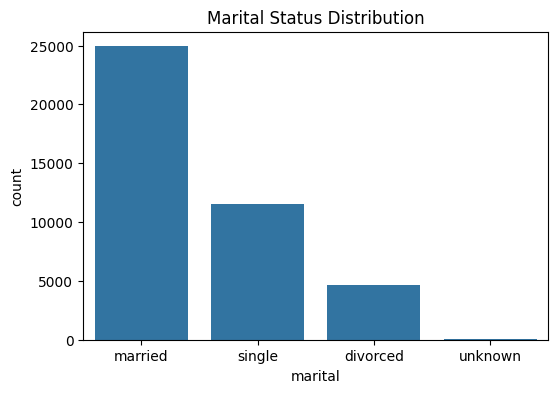

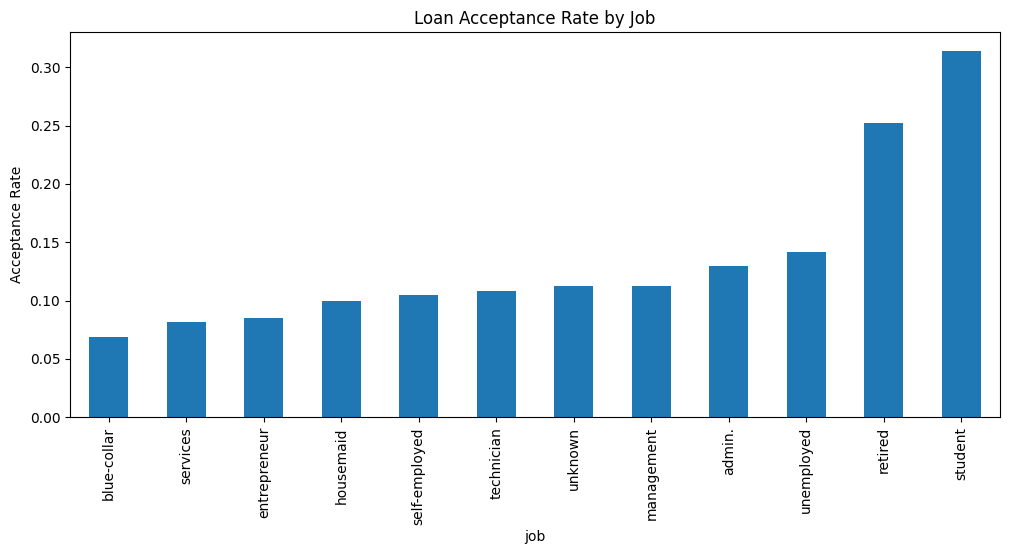

In [6]:

# =========================
# 4. EDA (AGE, JOB, MARITAL)
# =========================

plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(x='job', data=df)
plt.xticks(rotation=45)
plt.title("Job Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='marital', data=df)
plt.title("Marital Status Distribution")
plt.show()

# Acceptance rate by job
job_acceptance = df.groupby('job')['y'].mean().sort_values()

plt.figure(figsize=(12,5))
job_acceptance.plot(kind='bar')
plt.title("Loan Acceptance Rate by Job")
plt.ylabel("Acceptance Rate")
plt.show()


In [7]:

# =========================
# 5. DATA PREPROCESSING
# =========================

df_encoded = df.copy()

# Encode categorical variables
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Features and target
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:

# =========================
# 6. LOGISTIC REGRESSION MODEL
# =========================

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\n=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))



=== Logistic Regression Results ===
Accuracy: 0.9109007040543822
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:

# =========================
# 7. DECISION TREE MODEL
# =========================

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("\n=== Decision Tree Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))



=== Decision Tree Results ===
Accuracy: 0.9149065307113377
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.65      0.54      0.59       935

    accuracy                           0.91      8238
   macro avg       0.80      0.75      0.77      8238
weighted avg       0.91      0.91      0.91      8238



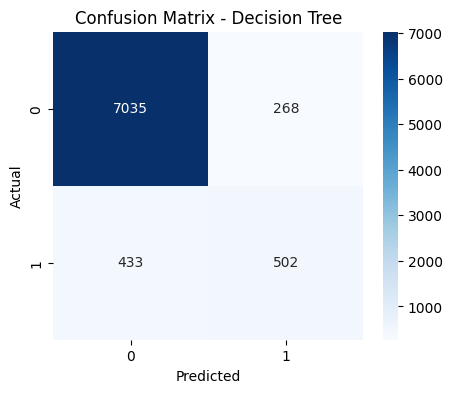

In [10]:

# =========================
# 8. CONFUSION MATRIX (BEST MODEL)
# =========================

cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [18]:

# =========================
# 9. BUSINESS INSIGHTS
# =========================

print("\n===== BUSINESS INSIGHTS =====")

# Age insight
print("\nAverage age of accepted customers:",
      df[df['y']==1]['age'].mean())




===== BUSINESS INSIGHTS =====

Average age of accepted customers: 40.91314655172414


In [19]:

# Job insight
print("\nTop job categories more likely to accept loan:")
print(df.groupby('job')['y'].mean().sort_values(ascending=False).head())



Top job categories more likely to accept loan:
job
student       0.314286
retired       0.252326
unemployed    0.142012
admin.        0.129726
management    0.112175
Name: y, dtype: float64


In [20]:

# Marital insight
print("\nAcceptance rate by marital status:")
print(df.groupby('marital')['y'].mean())


Acceptance rate by marital status:
marital
divorced    0.103209
married     0.101573
single      0.140041
unknown     0.150000
Name: y, dtype: float64


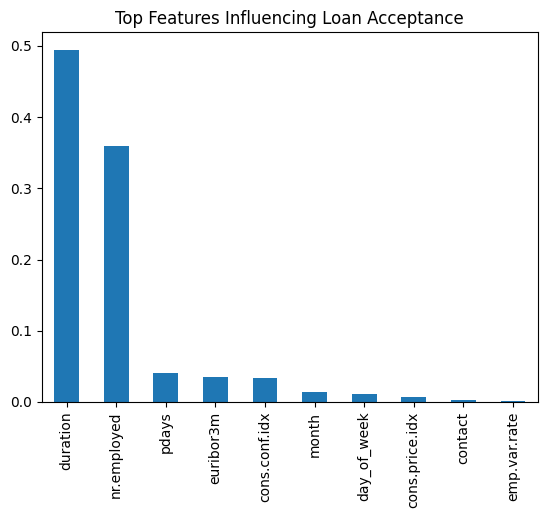

In [12]:

# =========================
# 10. FEATURE IMPORTANCE (DECISION TREE)
# =========================

feature_importance = pd.Series(tree_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features Influencing Loan Acceptance")
plt.show()

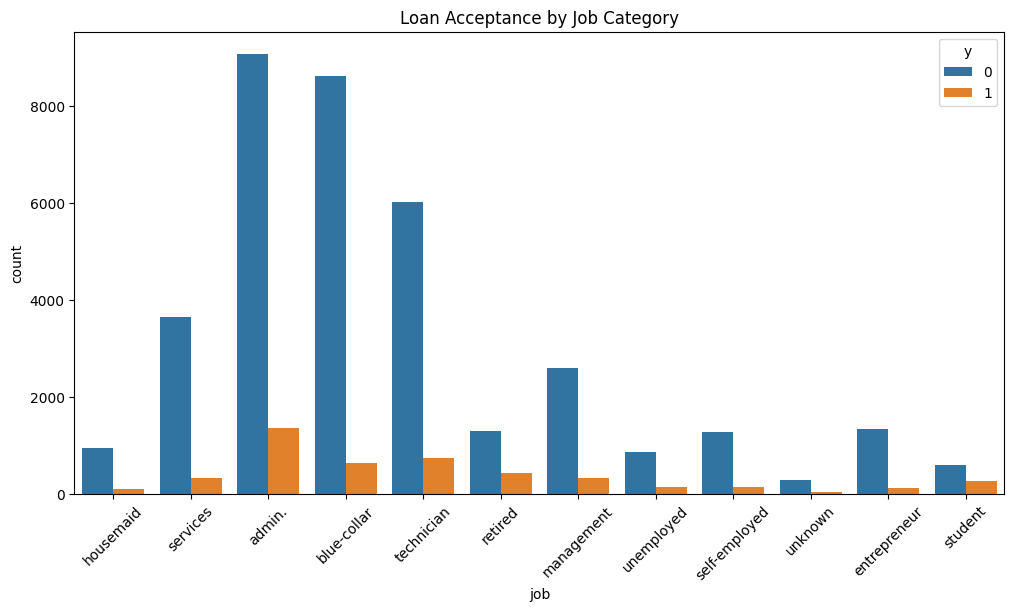

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(x='job', hue='y', data=df)
plt.title('Loan Acceptance by Job Category')
plt.xticks(rotation=45)
plt.show()

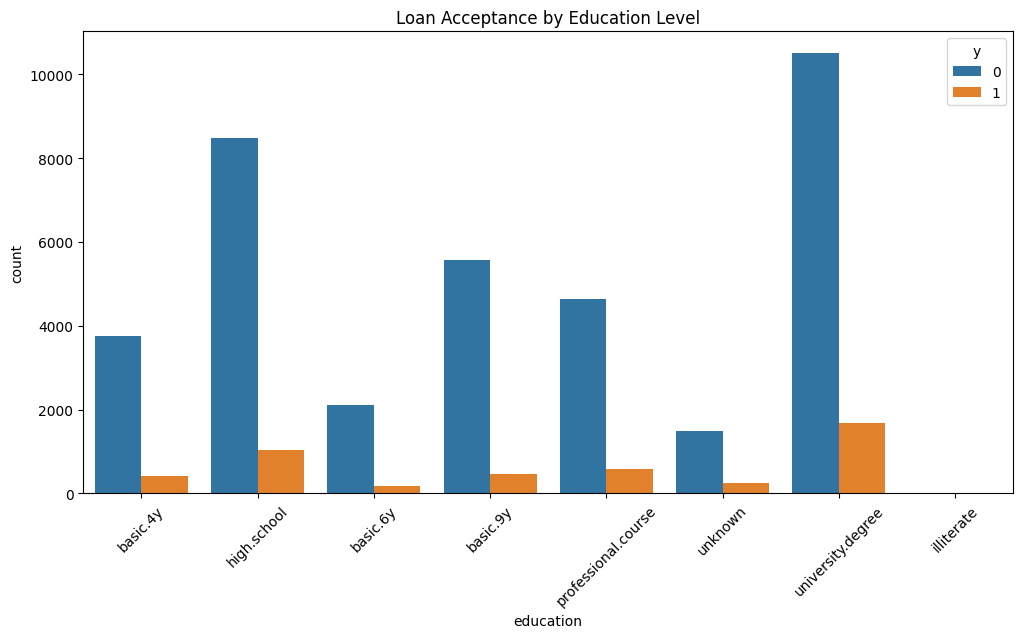

In [22]:
plt.figure(figsize=(12, 6))
sns.countplot(x='education', hue='y', data=df)
plt.title('Loan Acceptance by Education Level')
plt.xticks(rotation=45)
plt.show()

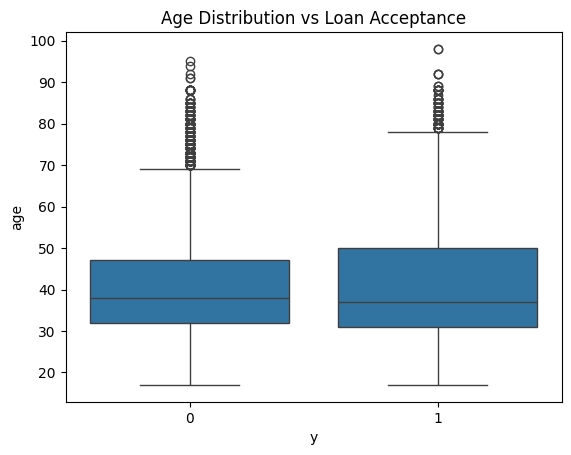

In [23]:
# Check average age of those who accepted vs those who didn't
sns.boxplot(x='y', y='age', data=df)
plt.title('Age Distribution vs Loan Acceptance')
plt.show()

In [24]:
# Define a function to find outlier boundaries
def find_outliers_iqr(data_column):
    Q1 = data_column.quantile(0.25)
    Q3 = data_column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Example: Check for 'age' outliers
lower, upper = find_outliers_iqr(df['age'])
print(f"Lower Bound: {lower}, Upper Bound: {upper}")

# Count how many outliers exist
outliers = df[(df['age'] < lower) | (df['age'] > upper)]
print(f"Number of outliers in Age: {len(outliers)}")

Lower Bound: 9.5, Upper Bound: 69.5
Number of outliers in Age: 469


In [25]:
# Keep only the data within the bounds
df_cleaned = df[(df['age'] >= lower) & (df['age'] <= upper)]

In [26]:
# Cap the values at the upper and lower bounds
df['age'] = df['age'].clip(lower=lower, upper=upper)

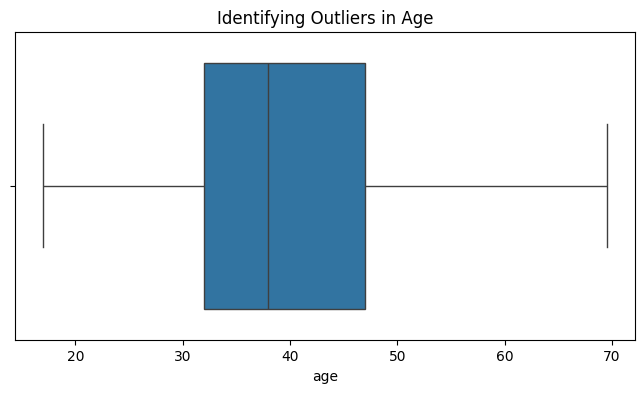

In [27]:
# Visualize outliers in the 'age' column
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['age'])
plt.title('Identifying Outliers in Age')
plt.show()

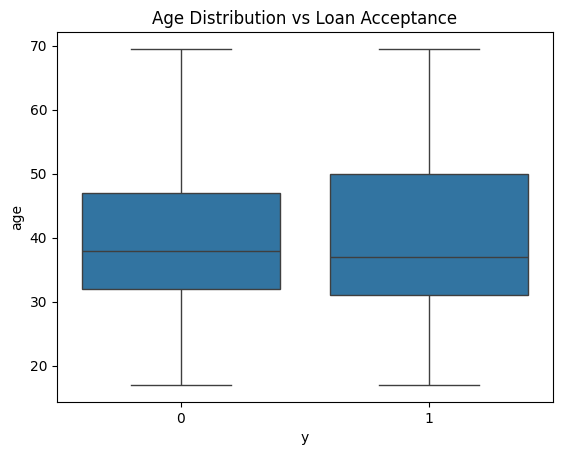

In [28]:
# Check average age of those who accepted vs those who didn't
sns.boxplot(x='y', y='age', data=df)
plt.title('Age Distribution vs Loan Acceptance')
plt.show()

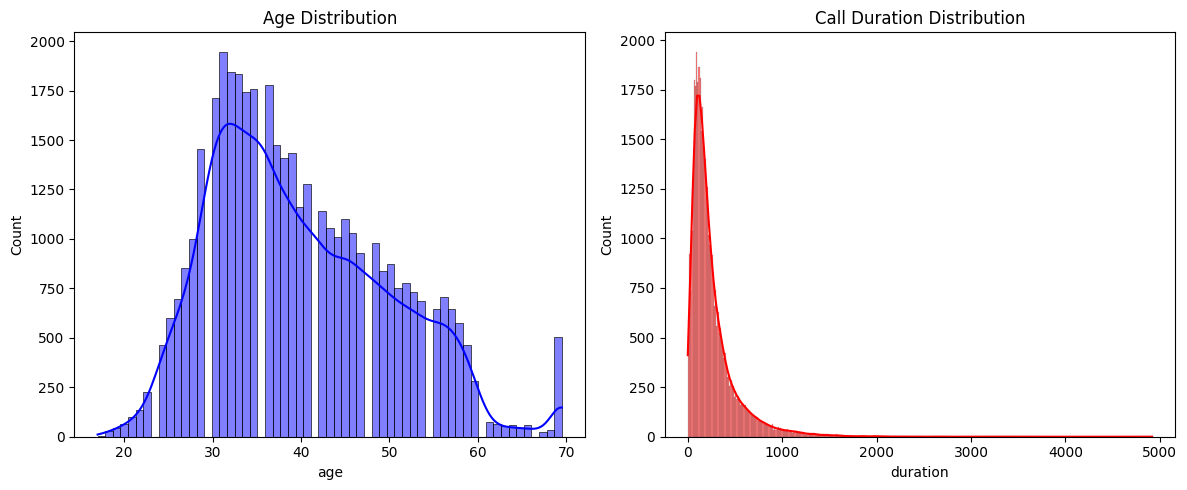

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure for multiple distributions
plt.figure(figsize=(12, 5))

# Plotting Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True, color='blue')
plt.title('Age Distribution')

# Plotting Duration Distribution (Commonly has many outliers)
plt.subplot(1, 2, 2)
sns.histplot(df['duration'], kde=True, color='red')
plt.title('Call Duration Distribution')

plt.tight_layout()
plt.show()

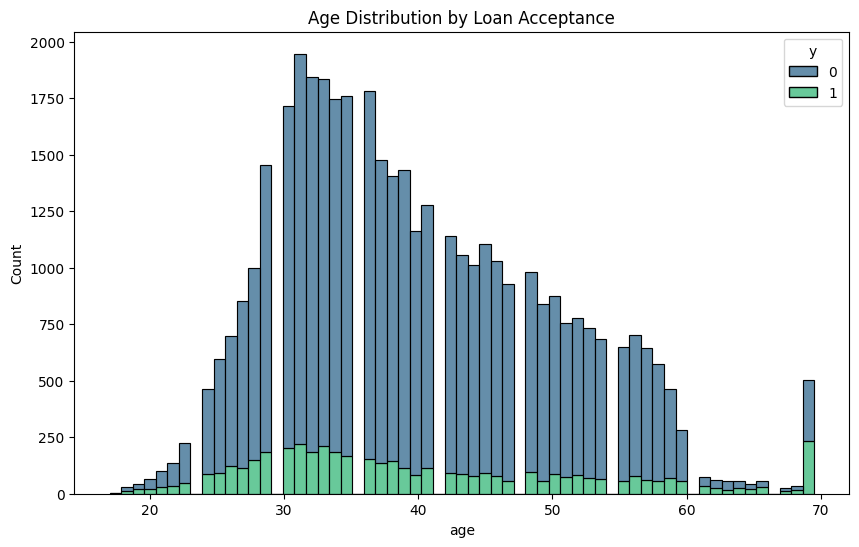

In [30]:
# Histogram overlaid by target variable 'y'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='y', multiple="stack", palette='viridis')
plt.title('Age Distribution by Loan Acceptance')
plt.show()

In [32]:
import joblib

joblib.dump(log_model, "model.pkl")
joblib.dump(tree_model, "model.pkl")
joblib.dump(X.columns, "features.pkl")

['features.pkl']